In [1]:
import ee
import json
import datetime
import geemap
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output
import os
import geopandas as gpd
import zipfile
import time
import matplotlib.pyplot as plt
import math
import urllib.request
from PIL import Image
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm
import io


In [2]:
# Authenticating of the GEE project to use
ee.Authenticate()
ee.Initialize(
    project= "ee-my-ndungu" #'vegetation-monitoring-474607'
)

In [7]:
# One step implementation

# Upload widget
upload_widget = widgets.FileUpload(
    accept='.zip,.geojson,.json,.shp,.dbf,.shx,.prj',
    multiple=False,
    description='📁 Upload AOI File'
)
display(upload_widget)

def wait_for_upload(widget):
    """Wait until file upload completes."""
    print("⏳ Waiting for file upload...")
    while not widget.value:
        time.sleep(1)
    print("✅ File uploaded!")

def save_uploaded_file(widget):
    """Save uploaded AOI locally."""
    uploaded_file = list(widget.value.values())[0] if isinstance(widget.value, dict) else widget.value[0]
    filename = uploaded_file['metadata']['name'] if isinstance(widget.value, dict) else uploaded_file['name']
    content = uploaded_file['content']
    with open(filename, 'wb') as f:
        f.write(content)
    return filename

def load_aoi_from_file(filepath):
    """Convert uploaded AOI to Earth Engine geometry."""
    ext = os.path.splitext(filepath)[1].lower()
    if ext == ".zip":
        extract_dir = "extracted_aoi"
        os.makedirs(extract_dir, exist_ok=True)
        with zipfile.ZipFile(filepath, "r") as zip_ref:
            zip_ref.extractall(extract_dir)
        shp_files = [f for f in os.listdir(extract_dir) if f.endswith(".shp")]
        gdf = gpd.read_file(os.path.join(extract_dir, shp_files[0]))
    else:
        gdf = gpd.read_file(filepath)

    ee_aoi = geemap.geopandas_to_ee(gdf)
    return ee_aoi

# Main workflow
wait_for_upload(upload_widget)
uploaded_path = save_uploaded_file(upload_widget)
aoi = load_aoi_from_file(uploaded_path)
print("🎯 AOI loaded into Earth Engine successfully!")


FileUpload(value=(), accept='.zip,.geojson,.json,.shp,.dbf,.shx,.prj', description='📁 Upload AOI File')

⏳ Waiting for file upload...
✅ File uploaded!
🎯 AOI loaded into Earth Engine successfully!


In [8]:
aoi

In [9]:
# Initialize the AOI into earth engine
def load_aoi(filepath):
    """Convert uploaded AOI file to Earth Engine geometry."""
    ext = os.path.splitext(filepath)[1].lower()
    if ext == ".zip":
        import zipfile
        extract_dir = "extracted_aoi"
        os.makedirs(extract_dir, exist_ok=True)
        with zipfile.ZipFile(filepath, "r") as zip_ref:
            zip_ref.extractall(extract_dir)
        shp_files = [f for f in os.listdir(extract_dir) if f.endswith(".shp")]
        if not shp_files:
            raise ValueError("No shapefile found in the uploaded zip.")
        gdf = gpd.read_file(os.path.join(extract_dir, shp_files[0]))
    else:
        gdf = gpd.read_file(filepath)

    print(f"✅ AOI CRS: {gdf.crs}")
    ee_aoi = geemap.geopandas_to_ee(gdf)
    return ee_aoi

# Load AOI into Earth Engine
aoi = load_aoi(uploaded_path)


✅ AOI CRS: EPSG:4326


In [10]:
# Preview AOI into interactive map
Map = geemap.Map()
Map.centerObject(aoi)
Map.addLayer(aoi, {'color': 'blue'}, 'AOI')
Map.addLayerControl()
Map


Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [11]:
# Initialize MODIS data collection
modis = ee.ImageCollection("MODIS/061/MOD13Q1").select(["NDVI", "EVI"])
start_date = "2024-01-01"
end_date = "2024-12-31"

modis_year = modis.filterBounds(aoi).filterDate(start_date, end_date)
print("Number of images:", modis_year.size().getInfo())


Number of images: 23


In [12]:
# Scale MODIS and compute indices
def scale_modis(img):
    return img.multiply(0.0001).copyProperties(img, img.propertyNames())

modis_scaled = modis_year.map(scale_modis)

def add_indices(img):
    ndvi = img.select('NDVI')
    evi = img.select('EVI')

    # Compute NDVI min & max for VCI
    ndvi_min = modis_scaled.select('NDVI').reduce(ee.Reducer.min())
    ndvi_max = modis_scaled.select('NDVI').reduce(ee.Reducer.max())
    vci = ndvi.subtract(ndvi_min).divide(ndvi_max.subtract(ndvi_min)).rename('VCI')

    return img.addBands(vci)

modis_indices = modis_scaled.map(add_indices)
print("✅ Bands in first image:", modis_indices.first().bandNames().getInfo())


✅ Bands in first image: ['NDVI', 'EVI', 'VCI']


In [13]:
# obtaining monthly comosites
year = 2024

def compute_monthly_composites(modis_indices, aoi, year=2024):
    """Compute monthly mean, min, and max composites for NDVI, EVI, and VCI."""
    results = []

    for month in range(1, 13):
        start = ee.Date.fromYMD(year, month, 1)
        end = start.advance(1, "month")

        monthly = modis_indices.filterDate(start, end).map(lambda img: img.clip(aoi))
        if monthly.size().getInfo() == 0:
            continue

        stats = {
            "mean": monthly.mean(),
            "min": monthly.min(),
            "max": monthly.max()
        }

        for stat, img in stats.items():
            img = img.set({
                "year": year,
                "month": month,
                "stat": stat
            })
            results.append(img)

    return ee.ImageCollection(results)

monthly_composites = compute_monthly_composites(modis_indices, aoi, year)
print("✅ Computed monthly composites (mean, min, max).")


✅ Computed monthly composites (mean, min, max).


In [ ]:
# Extract AOI level statistics
def extract_monthly_stats(monthly_composites, aoi, index="NDVI"):
    stats = []
    for month in range(1, 13):
        for stat in ["mean", "min", "max"]:
            img = monthly_composites.filter(
                ee.Filter.And(
                    ee.Filter.eq("month", month),
                    ee.Filter.eq("stat", stat)
                )
            ).first()
            if img:
                val = img.reduceRegion(
                    reducer=ee.Reducer.mean(),
                    geometry=aoi.geometry() if isinstance(aoi, ee.FeatureCollection) else aoi,
                    scale=250,
                    maxPixels=1e13
                ).get(index)
                val = val.getInfo() if val else None
                stats.append({"month": month, "stat": stat, "value": val})
    df = pd.DataFrame(stats)
    if not df.empty:
        df = df.pivot(index="month", columns="stat", values="value").reset_index()
        df["index"] = index
    return df

df_ndvi = extract_monthly_stats(monthly_composites, aoi, "NDVI")
df_evi = extract_monthly_stats(monthly_composites, aoi, "EVI")
df_vci = extract_monthly_stats(monthly_composites, aoi, "VCI")

df_all = pd.concat([df_ndvi, df_evi, df_vci], ignore_index=True)
print("✅ Extracted AOI-level statistics for NDVI, EVI, and VCI.")


In [15]:
# Plot monthly composite grids
def plot_monthly_composites(aoi, monthly_composites, index="NDVI", stat="mean", year=2024, filename=None):
    """Plot 12-month composite grid for a given index/stat and save as PNG."""
    fig, axes = plt.subplots(3, 4, figsize=(15, 10))
    axes = axes.flatten()

    for m in range(1, 13):
        img = monthly_composites.filter(
            ee.Filter.And(
                ee.Filter.eq("month", m),
                ee.Filter.eq("stat", stat)
            )
        ).first()
        if not img:
            continue

        try:
            url = img.select(index).getThumbURL({
                "min": 0.0, "max": 1.0,
                "palette": ["white", "yellow", "green"],
                "region": aoi.geometry() if isinstance(aoi, ee.FeatureCollection) else aoi,
                "dimensions": 300
            })
            image_bytes = urllib.request.urlopen(url).read()
            im = Image.open(io.BytesIO(image_bytes))
            axes[m-1].imshow(im)
            axes[m-1].set_title(f"{index} ({stat.upper()}) - {year}-{m:02d}")
            axes[m-1].axis("off")
        except Exception as e:
            axes[m-1].text(0.5, 0.5, "No data", ha="center", va="center")
            axes[m-1].axis("off")

    plt.suptitle(f"{index} ({stat.upper()}) Monthly Composites - {year}", fontsize=16, weight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if filename:
        plt.savefig(filename, dpi=300)
        print(f"✅ Saved {index} ({stat}) composites grid to: {filename}")
    plt.show()


✅ Saved NDVI (mean) composites grid to: NDVI_mean_composites.png


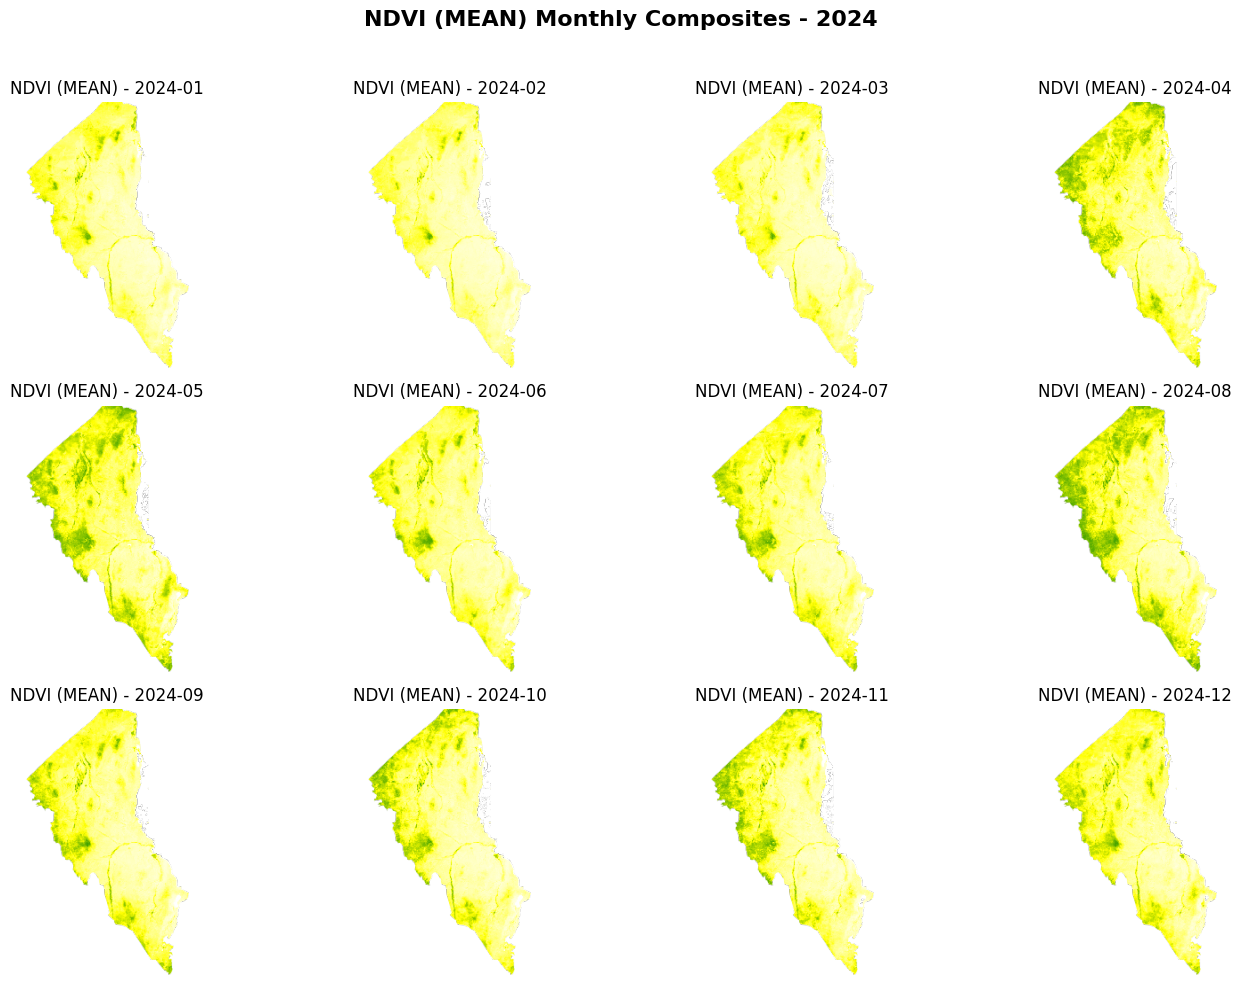

✅ Saved NDVI (max) composites grid to: NDVI_max_composites.png


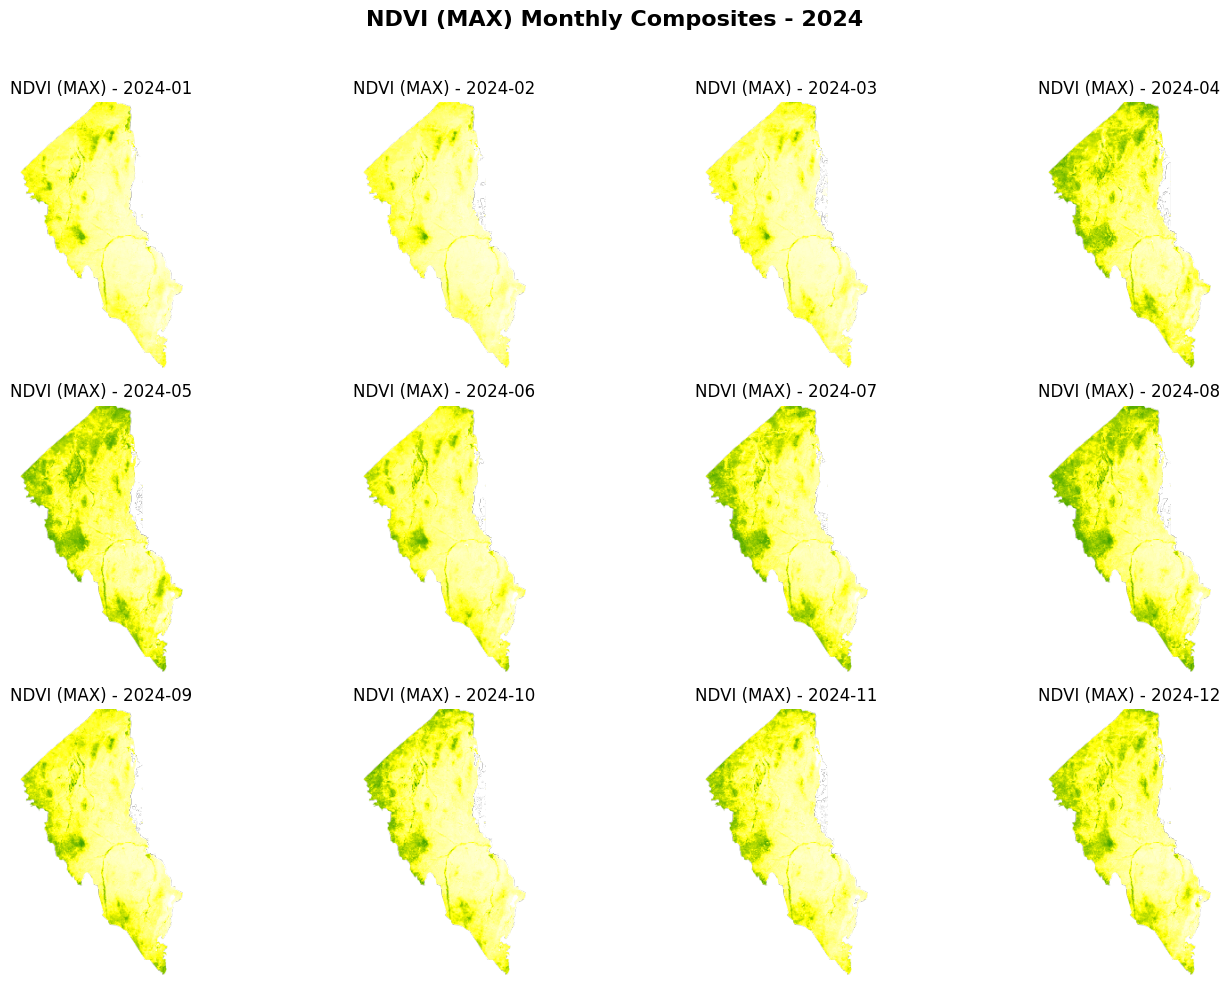

✅ Saved NDVI (min) composites grid to: NDVI_min_composites.png


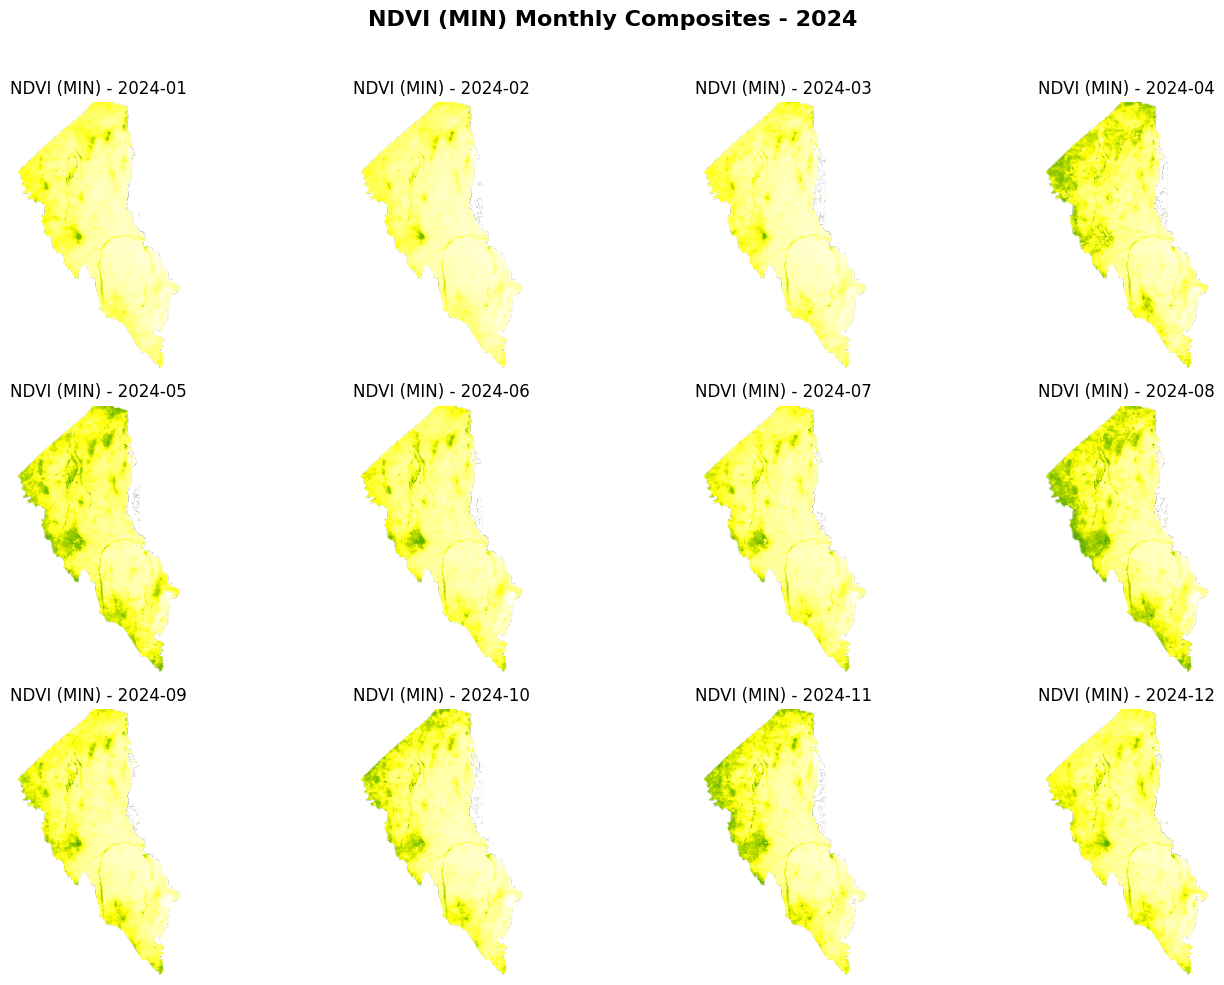

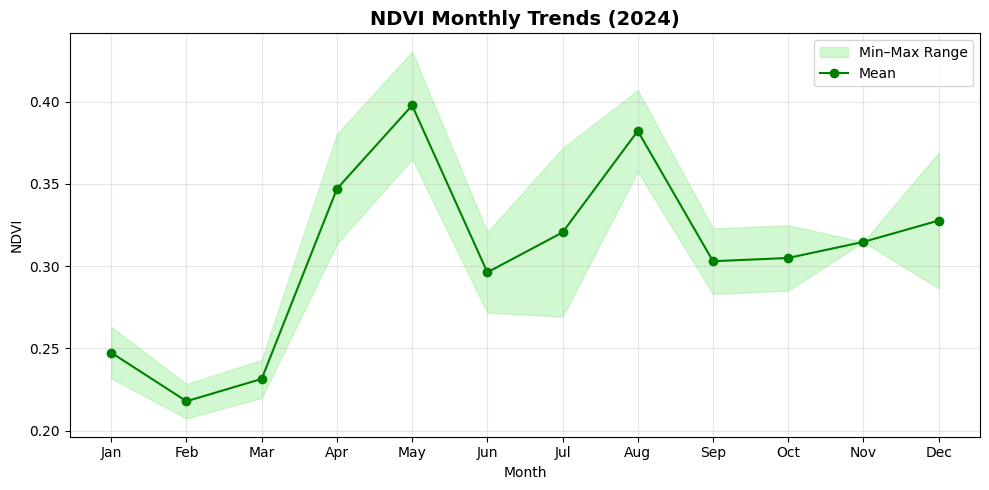

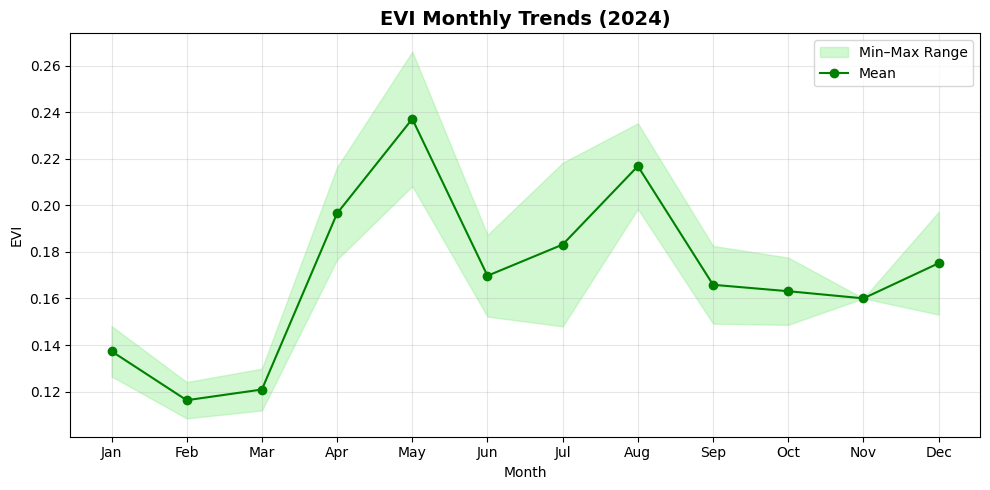

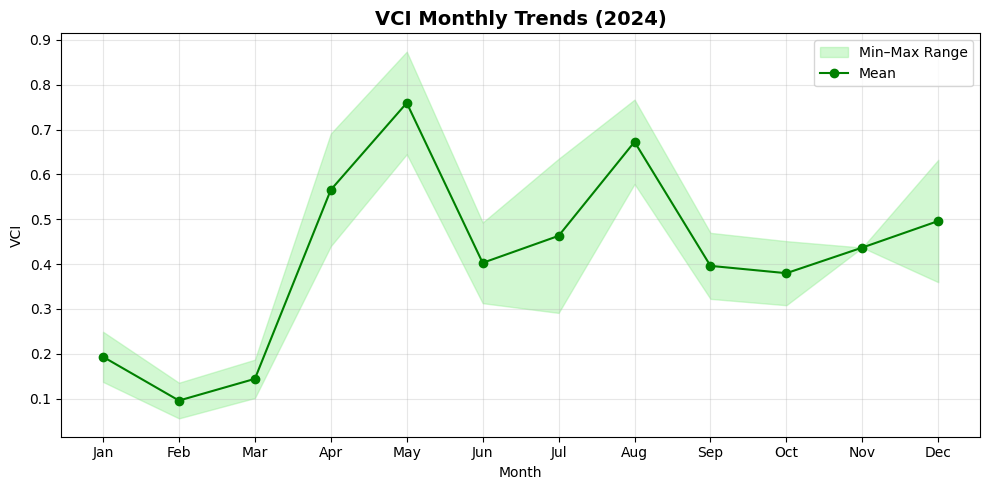

✅ Exported stats: monthly_veg_indices_summary_2024.csv


In [16]:
# Plot trend lines
def plot_monthly_trends(df, index="NDVI"):
    d = df[df["index"] == index]
    if d.empty:
        print(f"No data for {index}")
        return

    plt.figure(figsize=(10, 5))
    plt.fill_between(d["month"], d["min"], d["max"], color="lightgreen", alpha=0.4, label="Min–Max Range")
    plt.plot(d["month"], d["mean"], color="green", marker="o", label="Mean")

    plt.title(f"{index} Monthly Trends ({year})", fontsize=14, weight="bold")
    plt.xlabel("Month")
    plt.ylabel(index)
    plt.xticks(range(1, 13), ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example calls:
plot_monthly_composites(aoi, monthly_composites, "NDVI", stat="mean", year=year, filename="NDVI_mean_composites.png")
plot_monthly_composites(aoi, monthly_composites, "NDVI", stat="max", year=year, filename="NDVI_max_composites.png")
plot_monthly_composites(aoi, monthly_composites, "NDVI", stat="min", year=year, filename="NDVI_min_composites.png")

plot_monthly_trends(df_all, "NDVI")
plot_monthly_trends(df_all, "EVI")
plot_monthly_trends(df_all, "VCI")

df_all.to_csv(f"monthly_veg_indices_summary_{year}.csv", index=False)
print(f"✅ Exported stats: monthly_veg_indices_summary_{year}.csv")

In [15]:
# Plot and save trend lines
def plot_and_save_trends(df, indices=["NDVI", "EVI", "VCI"], year=2024, output_dir="trend_lines"):
    """
    Generate and save monthly trend line plots (mean, min, max) for each vegetation index.
    """
    os.makedirs(output_dir, exist_ok=True)

    for index in indices:
        d = df[df["index"] == index]
        if d.empty:
            print(f"⚠️ No data available for {index}")
            continue

        plt.figure(figsize=(10, 5))
        plt.fill_between(d["month"], d["min"], d["max"], color="lightgreen", alpha=0.4, label="Min–Max Range")
        plt.plot(d["month"], d["mean"], color="green", marker="o", label="Mean", linewidth=2)

        plt.title(f"{index} Monthly Trends ({year})", fontsize=14, weight="bold")
        plt.xlabel("Month")
        plt.ylabel(index)
        plt.xticks(range(1, 13), ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()

        filename = os.path.join(output_dir, f"{index}_trend_{year}.png")
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        plt.close()
        print(f"✅ Saved trend plot for {index} → {filename}")

    print(f"\n📊 All trend plots saved in '{output_dir}/'")

# --- Example usage ---
plot_and_save_trends(df_all, indices=["NDVI", "EVI", "VCI"], year=year)


✅ Saved trend plot for NDVI → trend_lines\NDVI_trend_2024.png
✅ Saved trend plot for EVI → trend_lines\EVI_trend_2024.png
✅ Saved trend plot for VCI → trend_lines\VCI_trend_2024.png

📊 All trend plots saved in 'trend_lines/'


In [16]:
# Obtaining Monthly Composites
def monthly_composites(collection, year):
    results = []
    for m in range(1, 13):
        start = ee.Date.fromYMD(year, m, 1)
        end = start.advance(1, "month")

        monthly = collection.filterDate(start, end).mean().clip(aoi)
        stat = monthly.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi,
            scale=250,
            maxPixels=1e13
        )
        results.append({
            "Month": m,
            "NDVI": stat.get("NDVI"),
            "EVI": stat.get("EVI"),
            "VCI": stat.get("VCI")
        })
    return results

year = 2024
monthly_stats = monthly_composites(modis_indices, year)


In [17]:
# Convert to dataframe and Visualize
def ee_stat_to_dict(stat):
    """Safely convert Earth Engine computed values."""
    return {
        "Month": stat["Month"],
        "NDVI": stat["NDVI"].getInfo() if isinstance(stat["NDVI"], ee.ComputedObject) else stat["NDVI"],
        "EVI": stat["EVI"].getInfo() if isinstance(stat["EVI"], ee.ComputedObject) else stat["EVI"],
        "VCI": stat["VCI"].getInfo() if isinstance(stat["VCI"], ee.ComputedObject) else stat["VCI"]
    }

monthly_stats_client = [ee_stat_to_dict(s) for s in monthly_stats]

df = pd.DataFrame(monthly_stats_client)
df.to_csv("MODIS_Vegetation_Indices.csv", index=False)

print("✅ Exported CSV: MODIS_Vegetation_Indices.csv")
df


✅ Exported CSV: MODIS_Vegetation_Indices.csv


,Month,NDVI,EVI,VCI
0,1,0.247444,0.137337,0.193072
1,2,0.217928,0.116296,0.095513
2,3,0.231510,0.120894,0.143990
3,4,0.347030,0.196552,0.565651
4,5,0.397769,0.237124,0.759485
5,6,0.296284,0.169755,0.402739
6,7,0.320572,0.183150,0.462963
7,8,0.382266,0.216838,0.672752
8,9,0.303059,0.165878,0.396016
9,10,0.305023,0.163119,0.379683


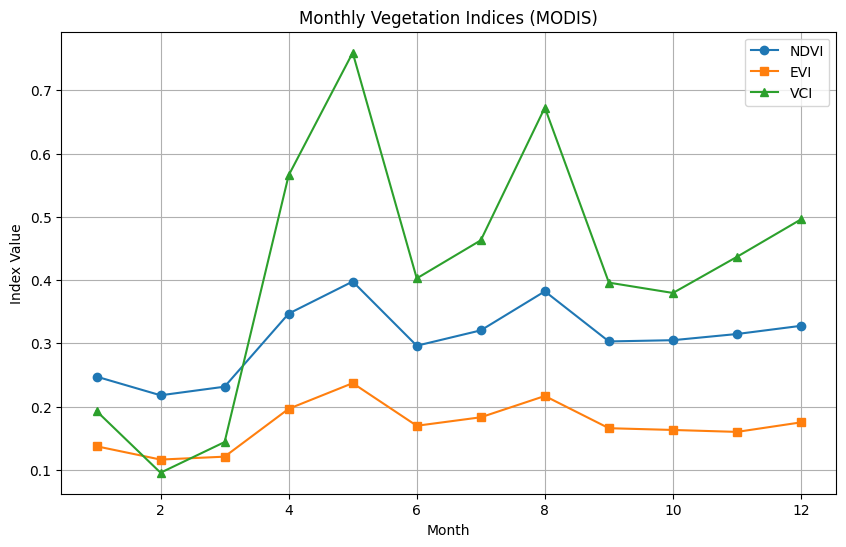

In [18]:
# Line Plots for each index
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(df["Month"], df["NDVI"], label="NDVI", marker='o')
plt.plot(df["Month"], df["EVI"], label="EVI", marker='s')
plt.plot(df["Month"], df["VCI"], label="VCI", marker='^')
plt.title("Monthly Vegetation Indices (MODIS)")
plt.xlabel("Month")
plt.ylabel("Index Value")
plt.legend()
plt.grid(True)
plt.show()


In [19]:
# Interactive Visualization in geemap

# Choose month to visualize
month_to_view = 5  # e.g., January
year = 2024

# Compute the monthly NDVI composite
start = ee.Date.fromYMD(year, month_to_view, 1)
end = start.advance(1, "month")

monthly_ndvi = (
    modis_indices
    .filterDate(start, end)
    .mean()
    .clip(aoi)
)

# NDVI visualization parameters
ndvi_vis = {
    "min": 0.0,
    "max": 1.0,
    "palette": [
        "FFFFFF", "CE7E45", "DF923D", "F1B555",
        "FCD163", "99B718", "74A901", "66A000",
        "529400", "3E8601", "207401", "056201",
        "004C00", "023B01", "012E01", "011D01", "011301"
    ],
}

# Create interactive geemap
Map = geemap.Map(center=[1.0, 36.0], zoom=6)
Map.addLayer(monthly_ndvi.select("NDVI"), ndvi_vis, f"NDVI {year}-{month_to_view:02d}")
Map.addLayer(aoi, {"color": "red"}, "AOI Boundary")

# ✅ FIX: only pass the color palette, not full dict
Map.add_colorbar_branca(colors=ndvi_vis["palette"], vmin=ndvi_vis["min"], vmax=ndvi_vis["max"], caption="NDVI")

# Show map
Map


Map(center=[1.0, 36.0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(c…

In [21]:
# Interactive NDVI viewer (an extension of the cell above) 

# --- Visualization settings ---
ndvi_palette = [
    "FFFFFF", "CE7E45", "DF923D", "F1B555",
    "FCD163", "99B718", "74A901", "66A000",
    "529400", "3E8601", "207401", "056201",
    "004C00", "023B01", "012E01", "011D01", "011301"
]

ndvi_vis = {"min": 0.0, "max": 1.0, "palette": ndvi_palette}

# --- Month selector widget ---
month_selector = widgets.Dropdown(
    options=[(f"{m:02d} - {name}", m) for m, name in enumerate(
        ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
         "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], start=1)],
    value=5,
    description="Month:",
)

# --- Function to update map ---
def update_ndvi(month):
    start = ee.Date.fromYMD(2024, month, 1)
    end = start.advance(1, "month")
    monthly_ndvi = modis_indices.filterDate(start, end).mean().clip(aoi)
    
    Map = geemap.Map(center=[1.0, 36.0], zoom=6)
    Map.addLayer(monthly_ndvi.select("NDVI"), ndvi_vis, f"NDVI 2024-{month:02d}")
    Map.addLayer(aoi, {"color": "red"}, "AOI Boundary")
    Map.add_colorbar_branca(
        colors=ndvi_vis["palette"],
        vmin=ndvi_vis["min"],
        vmax=ndvi_vis["max"],
        caption="NDVI"
    )
    display(Map)

# --- Interactive control ---
widgets.interact(update_ndvi, month=month_selector)


interactive(children=(Dropdown(description='Month:', index=4, options=(('01 - Jan', 1), ('02 - Feb', 2), ('03 …

<function __main__.update_ndvi(month)>

In [22]:
# Inteactive EVI viewer
#evi_palette = [
   # "FFFFFF", "ECE7F2", "D0D1E6", "A6BDDB",
   # "74A9CF", "3690C0", "0570B0", "045A8D", "023858"
#]
evi_palette = [
    "FFFFFF", "CE7E45", "DF923D", "F1B555",
    "FCD163", "99B718", "74A901", "66A000",
    "529400", "3E8601", "207401", "056201",
    "004C00", "023B01", "012E01", "011D01", "011301"
]
evi_vis = {"min": 0.0, "max": 1.0, "palette": evi_palette}

def update_evi(month):
    start = ee.Date.fromYMD(2024, month, 1)
    end = start.advance(1, "month")
    monthly_evi = modis_indices.filterDate(start, end).mean().clip(aoi)
    
    Map = geemap.Map(center=[1.0, 36.0], zoom=6)
    Map.addLayer(monthly_evi.select("EVI"), evi_vis, f"EVI 2024-{month:02d}")
    Map.addLayer(aoi, {"color": "red"}, "AOI Boundary")
    Map.add_colorbar_branca(
        colors=evi_vis["palette"],
        vmin=evi_vis["min"],
        vmax=evi_vis["max"],
        caption="EVI"
    )
    display(Map)

widgets.interact(update_evi, month=month_selector)


interactive(children=(Dropdown(description='Month:', index=4, options=(('01 - Jan', 1), ('02 - Feb', 2), ('03 …

<function __main__.update_evi(month)>

In [23]:
# Interactive VCI viewer
vci_palette = [
    "red", "orange", "yellow", "lightgreen", "green"
]
vci_vis = {"min": 0.0, "max": 1.0, "palette": vci_palette}

def update_vci(month):
    start = ee.Date.fromYMD(2024, month, 1)
    end = start.advance(1, "month")
    monthly_vci = modis_indices.filterDate(start, end).mean().clip(aoi)
    
    Map = geemap.Map(center=[1.0, 36.0], zoom=6)
    Map.addLayer(monthly_vci.select("VCI"), vci_vis, f"VCI 2024-{month:02d}")
    Map.addLayer(aoi, {"color": "red"}, "AOI Boundary")
    Map.add_colorbar_branca(
        colors=vci_vis["palette"],
        vmin=vci_vis["min"],
        vmax=vci_vis["max"],
        caption="VCI"
    )
    display(Map)

widgets.interact(update_vci, month=month_selector)


interactive(children=(Dropdown(description='Month:', index=4, options=(('01 - Jan', 1), ('02 - Feb', 2), ('03 …

<function __main__.update_vci(month)>

### Side by side comparison dashboard

In [28]:
import geemap
print(geemap.__version__)


0.35.3


In [32]:
monthly = modis_indices.filterDate('2024-03-01', '2024-04-01').mean().clip(aoi.geometry())
print(monthly.bandNames().getInfo())


['NDVI', 'EVI', 'VCI']


In [33]:
# --- Visualization parameters ---
vis_params = {
    "NDVI": {
        "min": 0.0, "max": 1.0,
        "palette": [
            "FFFFFF", "CE7E45", "DF923D", "F1B555",
            "FCD163", "99B718", "74A901", "66A000",
            "529400", "3E8601", "207401", "056201",
            "004C00", "023B01", "012E01", "011D01", "011301"
        ]
    },
    "EVI": {
        "min": 0.0, "max": 1.0,
        "palette": [
            "FFFFFF", "ECE7F2", "D0D1E6", "A6BDDB",
            "74A9CF", "3690C0", "0570B0", "045A8D", "023858"
        ]
    },
    "VCI": {
        "min": 0.0, "max": 1.0,
        "palette": ["red", "orange", "yellow", "lightgreen", "green"]
    }
}

# --- Month selector ---
month_selector = widgets.Dropdown(
    options=[(f"{m:02d} - {name}", m) for m, name in enumerate(
        ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
         "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], start=1)],
    value=1,
    description="Month:",
)

def update_comparison(month):
    start = ee.Date.fromYMD(2024, month, 1)
    end = start.advance(1, "month")

    # Convert AOI to a Geometry (works for FeatureCollection or Feature)
    aoi_geom = aoi.geometry() if isinstance(aoi, ee.FeatureCollection) else aoi

    # Create monthly composite
    monthly = modis_indices.filterDate(start, end).mean().clip(aoi_geom)

    # Get AOI center
    center_coords = aoi_geom.centroid().coordinates().getInfo()[::-1]

    # Create maps
    Map_NDVI = geemap.Map(center=center_coords, zoom=7, height="400px")
    Map_EVI = geemap.Map(center=center_coords, zoom=7, height="400px")
    Map_VCI = geemap.Map(center=center_coords, zoom=7, height="400px")

    # --- NDVI ---
    Map_NDVI.addLayer(monthly.select("NDVI"), vis_params["NDVI"], f"NDVI {month:02d}/2024")
    Map_NDVI.addLayer(aoi_geom, {"color": "red"}, "AOI Boundary")
    Map_NDVI.add_colorbar_branca(
        colors=vis_params["NDVI"]["palette"],
        vmin=vis_params["NDVI"]["min"],
        vmax=vis_params["NDVI"]["max"],
        caption="NDVI"
    )

    # --- EVI ---
    Map_EVI.addLayer(monthly.select("EVI"), vis_params["EVI"], f"EVI {month:02d}/2024")
    Map_EVI.addLayer(aoi_geom, {"color": "red"}, "AOI Boundary")
    Map_EVI.add_colorbar_branca(
        colors=vis_params["EVI"]["palette"],
        vmin=vis_params["EVI"]["min"],
        vmax=vis_params["EVI"]["max"],
        caption="EVI"
    )

    # --- VCI ---
    Map_VCI.addLayer(monthly.select("VCI"), vis_params["VCI"], f"VCI {month:02d}/2024")
    Map_VCI.addLayer(aoi_geom, {"color": "red"}, "AOI Boundary")
    Map_VCI.add_colorbar_branca(
        colors=vis_params["VCI"]["palette"],
        vmin=vis_params["VCI"]["min"],
        vmax=vis_params["VCI"]["max"],
        caption="VCI"
    )

    # ✅ Properly link 3 maps horizontally
    linked_maps = geemap.linked_maps(
        maps=[Map_NDVI, Map_EVI, Map_VCI],
        labels=["NDVI", "EVI", "VCI"],
        rows=1, cols=3,
        height="450px",
        width="100%",
        orientation="horizontal"
    )

    display(linked_maps)


# Interactive control
widgets.interactive(update_comparison, month=month_selector)


interactive(children=(Dropdown(description='Month:', options=(('01 - Jan', 1), ('02 - Feb', 2), ('03 - Mar', 3…

### Visualizing all the monthly composites per Index

In [24]:

# --- Visualization settings ---
vis_params = {
    "NDVI": {"min": 0.0, "max": 1.0, "palette": ["brown", "yellow", "green"]},
    "EVI": {"min": 0.0, "max": 1.0, "palette": ["blue", "white", "green"]},
    "VCI": {"min": 0.0, "max": 1.0, "palette": ["red", "yellow", "green"]},
}

def plot_monthly_composites(aoi, modis_indices, index="NDVI", year=2024, filename=None):
    """
    Creates a grid of monthly mean composites for the given vegetation index,
    adds a color scale, and saves the layout as a PNG.
    """
    fig, axes = plt.subplots(3, 4, figsize=(20, 10))
    axes = axes.flatten()
    
    # Determine visualization range and color map
    vmin = vis_params[index]["min"]
    vmax = vis_params[index]["max"]
    palette = vis_params[index]["palette"]
    cmap = ListedColormap(palette)
    norm = BoundaryNorm(np.linspace(vmin, vmax, len(palette)), cmap.N)
    
    for month in range(1, 13):
        start = ee.Date.fromYMD(year, month, 1)
        end = start.advance(1, "month")
        img = modis_indices.filterDate(start, end).mean().select(index).clip(aoi)

        # Generate Earth Engine thumbnail
        url = img.getThumbURL({
            "region": aoi.geometry() if isinstance(aoi, ee.FeatureCollection) else aoi,
            "min": vmin,
            "max": vmax,
            "palette": palette,
            "dimensions": 400,
        })

        # Read image directly from URL
        with urllib.request.urlopen(url) as response:
            im = Image.open(response)
            im = np.array(im)

        # Plot month composite
        ax = axes[month-1]
        ax.imshow(im)
        ax.set_title(f"{index} - {year}-{month:02d}", fontsize=10)
        ax.axis("off")

    # Add a shared colorbar
    cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.02])  # [left, bottom, width, height]
    cb = plt.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        cax=cbar_ax,
        orientation="horizontal"
    )
    cb.set_label(f"{index} Value", fontsize=12)
    
    # Layout + save
    plt.suptitle(f"{index} Monthly Composites ({year})", fontsize=20, weight="bold", y=1.02)
    plt.tight_layout(rect=[0, 0.07, 1, 0.97])

    if filename is None:
        filename = f"{index.lower()}_monthly_composites_{year}.png"
    plt.savefig(filename, dpi=200, bbox_inches="tight")
    plt.close()
    
    print(f"✅ Saved {index} monthly composites with color scale to: {filename}")


# --- Example usage ---
plot_monthly_composites(aoi, modis_indices, index="NDVI", year=2024)
plot_monthly_composites(aoi, modis_indices, index="EVI", year=2024)
plot_monthly_composites(aoi, modis_indices, index="VCI", year=2024)


✅ Saved NDVI monthly composites with color scale to: ndvi_monthly_composites_2024.png
✅ Saved EVI monthly composites with color scale to: evi_monthly_composites_2024.png
✅ Saved VCI monthly composites with color scale to: vci_monthly_composites_2024.png


### Automated Export & Folder Structure pipeline

In [25]:
# --- MASTER EXPORT FUNCTION ---
def generate_full_report(aoi, modis_indices, df_all, year=2024, output_dir="outputs"):
    """
    Creates a complete folder structure with:
    - Monthly composite grids (mean, min, max) for each index
    - Trend line plots
    - Exported summary CSV
    """

    os.makedirs(output_dir, exist_ok=True)
    composites_dir = os.path.join(output_dir, "composites")
    trends_dir = os.path.join(output_dir, "trends")
    os.makedirs(composites_dir, exist_ok=True)
    os.makedirs(trends_dir, exist_ok=True)

    # ---------------------
    # 1️⃣ Composite Plots (mean, min, max)
    # ---------------------
    def plot_monthly_composites(aoi, modis_indices, index, year, method="mean"):
        fig, axes = plt.subplots(3, 4, figsize=(14, 8))
        axes = axes.flatten()

        for month in range(1, 13):
            start = ee.Date.fromYMD(year, month, 1)
            end = start.advance(1, "month")

            # Compute composite using selected method
            if method == "mean":
                img = modis_indices.filterDate(start, end).mean().clip(aoi)
            elif method == "min":
                img = modis_indices.filterDate(start, end).min().clip(aoi)
            elif method == "max":
                img = modis_indices.filterDate(start, end).max().clip(aoi)
            else:
                raise ValueError("Method must be one of ['mean', 'min', 'max'].")

            vis_params = {
                "min": 0.0, "max": 1.0,
                "palette": [
                    "FFFFFF", "CE7E45", "DF923D", "F1B555",
                    "FCD163", "99B718", "74A901", "66A000",
                    "529400", "3E8601", "207401", "056201",
                    "004C00", "023B01", "012E01", "011D01", "011301"
                ]
            }

            # Get a thumbnail
            url = img.select(index).getThumbURL({
                "region": aoi.geometry(),
                "min": vis_params["min"],
                "max": vis_params["max"],
                "palette": vis_params["palette"],
                "dimensions": 300,
            })

            try:
                im = np.array(Image.open(urllib.request.urlopen(url)))
                axes[month-1].imshow(im)
            except Exception as e:
                axes[month-1].text(0.5, 0.5, "No Data", ha='center', va='center', fontsize=8)

            axes[month-1].set_title(f"{index} {year}-{month:02d}")
            axes[month-1].axis("off")

        plt.suptitle(f"{index} - {method.capitalize()} Composite ({year})", fontsize=16, weight="bold")
        plt.tight_layout(rect=[0, 0, 1, 0.96])

        filename = os.path.join(composites_dir, f"{index}_{method}_{year}.png")
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        plt.close()
        print(f"✅ Saved: {filename}")

    for index in ["NDVI", "EVI", "VCI"]:
        for method in ["mean", "min", "max"]:
            plot_monthly_composites(aoi, modis_indices, index, year, method)

    # ---------------------
    # 2️⃣ Trend Line Plots
    # ---------------------
    def plot_trends(df, indices=["NDVI", "EVI", "VCI"], year=year):
        for index in indices:
            d = df[df["index"] == index]
            if d.empty:
                print(f"⚠️ No data for {index}")
                continue

            plt.figure(figsize=(10, 5))
            plt.fill_between(d["month"], d["min"], d["max"], color="lightgreen", alpha=0.4, label="Min–Max Range")
            plt.plot(d["month"], d["mean"], color="green", marker="o", linewidth=2, label="Mean")
            plt.title(f"{index} Monthly Trends ({year})", fontsize=14, weight="bold")
            plt.xlabel("Month")
            plt.ylabel(index)
            plt.xticks(range(1, 13), ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
            plt.grid(alpha=0.3)
            plt.legend()
            plt.tight_layout()

            filename = os.path.join(trends_dir, f"{index}_trend_{year}.png")
            plt.savefig(filename, dpi=300, bbox_inches="tight")
            plt.close()
            print(f"📈 Saved trend line: {filename}")

    plot_trends(df_all)

    # ---------------------
    # 3️⃣ Export Summary CSV
    # ---------------------
    csv_path = os.path.join(output_dir, f"monthly_summary_{year}.csv")
    df_all.to_csv(csv_path, index=False)
    print(f"📊 CSV exported: {csv_path}")

    print("\n🎉 Full report generated successfully!")

# --- Run the full report generation ---
generate_full_report(aoi, modis_indices, df_all, year=2024)


✅ Saved: outputs\composites\NDVI_mean_2024.png
✅ Saved: outputs\composites\NDVI_min_2024.png
✅ Saved: outputs\composites\NDVI_max_2024.png
✅ Saved: outputs\composites\EVI_mean_2024.png
✅ Saved: outputs\composites\EVI_min_2024.png
✅ Saved: outputs\composites\EVI_max_2024.png
✅ Saved: outputs\composites\VCI_mean_2024.png
✅ Saved: outputs\composites\VCI_min_2024.png
✅ Saved: outputs\composites\VCI_max_2024.png
📈 Saved trend line: outputs\trends\NDVI_trend_2024.png
📈 Saved trend line: outputs\trends\EVI_trend_2024.png
📈 Saved trend line: outputs\trends\VCI_trend_2024.png
📊 CSV exported: outputs\monthly_summary_2024.csv

🎉 Full report generated successfully!


### Generate a pdf report

In [27]:
pip install reportlab


   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.0 MB 882.6 kB/s eta 0:00:02
   ---------------- ----------------------- 0.8/2.0 MB 907.1 kB/s eta 0:00:02
   --------------------- ------------------ 1.0/2.0 MB 931.8 kB/s eta 0:00:01
   --------------------- ------------------ 1.0/2.0 MB 931.8 kB/s eta 0:00:01
   -------------------------- ------------- 1.3/2.0 MB 907.1 kB/s eta 0:00:01
   -------------------------------- ------- 1.6/2.0 MB 911.5 kB/s eta 0:00:01
   ------------------------------------- -- 1.8/2.0 MB 915.0 kB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 880.8 kB/s  0:00:02


In [35]:
pip install mss

Note: you may need to restart the kernel to use updated packages.


In [28]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Image as RLImage, Spacer, Table, TableStyle, PageBreak
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet
import pandas as pd
import json

In [39]:


def generate_aoi_map(aoi, output_dir="outputs"):
    """Generate AOI map and basic info (area, centroid, bounding box)."""
    os.makedirs(output_dir, exist_ok=True)
    map_path = os.path.join(output_dir, "aoi_map.png")
    info_path = os.path.join(output_dir, "aoi_info.json")

    # --- Ensure we’re working with a geometry ---
    if isinstance(aoi, ee.FeatureCollection):
        geom = aoi.geometry()
    elif isinstance(aoi, ee.Feature):
        geom = aoi.geometry()
    else:
        geom = aoi  # already ee.Geometry

    # --- Compute AOI stats ---
    centroid = geom.centroid().coordinates().getInfo()
    bounds = geom.bounds().coordinates().getInfo()
    area_sqkm = geom.area().getInfo() / 1e6  # m² → km²

    # --- Create map ---
    Map = geemap.Map(center=centroid[::-1], zoom=7)
    Map.addLayer(geom, {"color": "red"}, "AOI Boundary")
    Map.to_image(filename=map_path)

    # --- Save AOI info ---
    aoi_info = {
        "centroid": {"lon": centroid[0], "lat": centroid[1]},
        "area_km2": round(area_sqkm, 2),
        "bounds": bounds
    }

    with open(info_path, "w") as f:
        json.dump(aoi_info, f, indent=2)

    print(f"🗺️ AOI map saved: {map_path}")
    print(f"📄 AOI info saved: {info_path}")

    return map_path, info_path


In [31]:

def create_pdf_report(output_dir="outputs", year=2024, include_aoi=True):
    pdf_path = os.path.join(output_dir, f"MODIS_Report_{year}.pdf")
    doc = SimpleDocTemplate(pdf_path, pagesize=landscape(A4))
    elements = []

    styles = getSampleStyleSheet()
    title_style = styles["Title"]
    heading_style = styles["Heading2"]
    normal = styles["BodyText"]

    # --- Title ---
    elements.append(Paragraph(f"MODIS Vegetation Index Report ({year})", title_style))
    elements.append(Spacer(1, 12))
    elements.append(Paragraph("Generated using MODIS MOD13Q1 data and Google Earth Engine via geemap.", normal))
    elements.append(Spacer(1, 24))

    # --- AOI Map Section ---
    if include_aoi:
        aoi_map = os.path.join(output_dir, "aoi_map.png")
        aoi_info = os.path.join(output_dir, "aoi_info.json")

        elements.append(Paragraph("Study Area (AOI)", heading_style))
        elements.append(Spacer(1, 8))

        if os.path.exists(aoi_map):
            elements.append(RLImage(aoi_map, width=600, height=400))
            elements.append(Spacer(1, 12))

        # Add AOI info if available
        if os.path.exists(aoi_info):
            with open(aoi_info, "r") as f:
                info = json.load(f)

            data = [
                ["Property", "Value"],
                ["Area (km²)", f"{info['area_km2']:,}"],
                ["Centroid (Lat, Lon)", f"{info['centroid']['lat']:.4f}, {info['centroid']['lon']:.4f}"],
                ["Bounding Box", f"{info['bounds']}"]
            ]

            table = Table(data)
            table.setStyle(TableStyle([
                ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#DDEEFF")),
                ("TEXTCOLOR", (0, 0), (-1, 0), colors.black),
                ("ALIGN", (0, 0), (-1, -1), "LEFT"),
                ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
                ("FONTSIZE", (0, 0), (-1, -1), 9),
                ("GRID", (0, 0), (-1, -1), 0.25, colors.grey),
            ]))
            elements.append(table)
            elements.append(Spacer(1, 20))
        else:
            elements.append(Paragraph("⚠️ AOI info not found.", normal))

    elements.append(PageBreak())

    # --- Monthly Composites ---
    elements.append(Paragraph("1. Monthly Composites", heading_style))
    elements.append(Spacer(1, 12))

    composites_dir = os.path.join(output_dir, "composites")
    for index in ["NDVI", "EVI", "VCI"]:
        for method in ["mean", "min", "max"]:
            img_path = os.path.join(composites_dir, f"{index}_{method}_{year}.png")
            if os.path.exists(img_path):
                elements.append(Paragraph(f"{index} ({method.capitalize()} Composite)", styles["Heading3"]))
                elements.append(Spacer(1, 8))
                elements.append(RLImage(img_path, width=700, height=350))
                elements.append(Spacer(1, 16))
        elements.append(PageBreak())

    # --- Trend Lines ---
    elements.append(Paragraph("2. Trend Line Plots", heading_style))
    elements.append(Spacer(1, 12))

    trends_dir = os.path.join(output_dir, "trends")
    for index in ["NDVI", "EVI", "VCI"]:
        img_path = os.path.join(trends_dir, f"{index}_trend_{year}.png")
        if os.path.exists(img_path):
            elements.append(Paragraph(f"{index} Monthly Trend ({year})", styles["Heading3"]))
            elements.append(Spacer(1, 8))
            elements.append(RLImage(img_path, width=700, height=350))
            elements.append(Spacer(1, 16))

    elements.append(PageBreak())

    # --- Summary Table ---
    elements.append(Paragraph("3. Summary Statistics", heading_style))
    elements.append(Spacer(1, 12))

    csv_path = os.path.join(output_dir, f"monthly_summary_{year}.csv")
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        data = [list(df.columns)] + df.values.tolist()

        table = Table(data, repeatRows=1)
        table.setStyle(TableStyle([
            ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#DDEEFF")),
            ("TEXTCOLOR", (0, 0), (-1, 0), colors.black),
            ("ALIGN", (0, 0), (-1, -1), "CENTER"),
            ("GRID", (0, 0), (-1, -1), 0.25, colors.grey),
            ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
            ("FONTSIZE", (0, 0), (-1, -1), 8),
        ]))
        elements.append(table)
    else:
        elements.append(Paragraph("⚠️ No summary CSV found.", normal))

    doc.build(elements)
    print(f"📘 PDF Report generated successfully: {pdf_path}")


In [40]:
# Generate AOI map + info
generate_aoi_map(aoi, "outputs")

# Create PDF report with AOI info
create_pdf_report("outputs", year=2024, include_aoi=True)


🗺️ AOI map saved: outputs\aoi_map.png
📄 AOI info saved: outputs\aoi_info.json
📘 PDF Report generated successfully: outputs\MODIS_Report_2024.pdf
